In [37]:
!pip install pandasql

In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pandasql import sqldf
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Age Group
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly,Senior
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly,Young
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly,Adult
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly,Young
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually,Adult


****Descriptive Statistics (Univariate Analysis)****


This section provides a high-level overview of your data's health and distribution.  
Numerical Summary: Using .describe() gives you the Mean, Median, and Standard Deviation. For example, knowing the average Purchase Amount helps the business set revenue benchmarks.  
Histograms: These charts show the "shape" of your data.  
The Purchase Amount Histogram helps identify if most customers are buying budget items or premium products.  
The Season Countplot reveals which time of year is busiest, which is critical for inventory planning.:

In [39]:

print(df[['Age','Purchase Amount (USD)','Review Rating','Previous Purchases']].describe())

               Age  Purchase Amount (USD)  Review Rating  Previous Purchases
count  3900.000000            3900.000000    3900.000000         3900.000000
mean     44.068462              59.764359       3.750538           25.351538
std      15.207589              23.685392       0.713589           14.447125
min      18.000000              20.000000       2.500000            1.000000
25%      31.000000              39.000000       3.100000           13.000000
50%      44.000000              60.000000       3.800000           25.000000
75%      57.000000              81.000000       4.400000           38.000000
max      70.000000             100.000000       5.000000           50.000000


/tmp/ipykernel_7606/3085306000.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Season',data=df,palette='viridis')


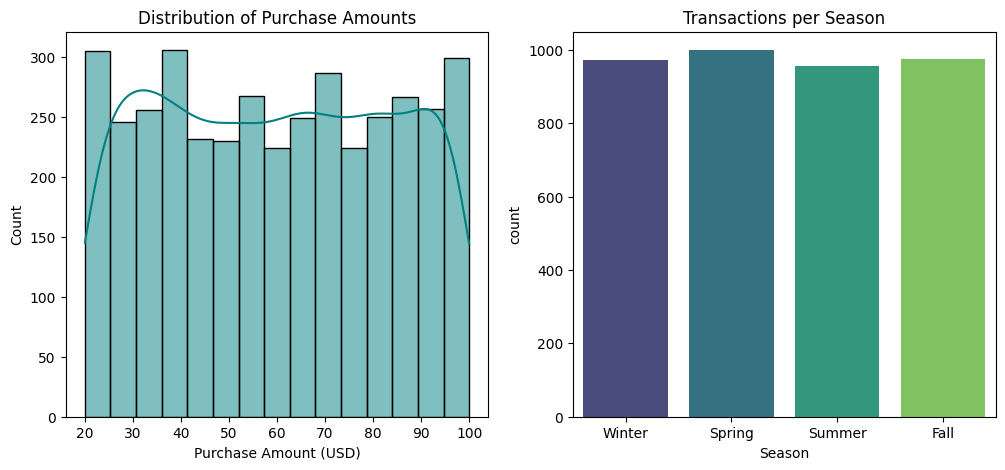

In [40]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['Purchase Amount (USD)'],kde=True,color='teal')
plt.title('Distribution of Purchase Amounts')
plt.subplot(1,2,2)
sns.countplot(x='Season',data=df,palette='viridis')
plt.title('Transactions per Season')
plt.show()

** SQL for Business Questions**

The script uses pysqldf to answer specific business problems using standard SQL syntax.  
Top 5 Items (Q1): By using SUM and GROUP BY, you identify which products are your "cash cows". This tells the business where to focus its marketing budget.  
Gender Spend (Q2): Using AVG allows you to see if one gender has a higher purchasing power than the other.  
Order Frequency (Q3): This helps analyze "User Acquisition Trends" by showing if customers prefer shopping weekly, monthly, or annually

In [41]:
pysqldf=lambda q: sqldf(q,globals())
q_sql = """
SELECT "Item Purchased" , SUM("Purchase Amount (USD)") as Total_Revenue
FROM df
GROUP BY "Item Purchased"
ORDER BY Total_Revenue DESC
LIMIT 5;
"""
print(pysqldf(q_sql))

  Item Purchased  Total_Revenue
0         Blouse          10410
1          Shirt          10332
2          Dress          10320
3          Pants          10090
4        Jewelry          10010


Q2: analyzing average spend by gender

In [42]:
q_sql_gender = """
SELECT Gender , AVG("Purchase Amount (USD)") as Avg_Spend
FROM df
GROUP BY Gender;
"""
print(pysqldf(q_sql_gender))

   Gender  Avg_Spend
0  Female  60.249199
1    Male  59.536199


Q3: Examining order count based on purchase frequnecy

In [43]:
q_sql_frequency = """
SELECT "Frequency of Purchases", COUNT(*) as Order_Count
FROM df
GROUP BY "Frequency of Purchases"
ORDER BY Order_Count DESC;
"""
print(pysqldf(q_sql_frequency))

  Frequency of Purchases  Order_Count
0         Every 3 Months          584
1               Annually          572
2              Quarterly          563
3                Monthly          553
4              Bi-Weekly          547
5            Fortnightly          542
6                 Weekly          539


Q4: Avg loaction rating

In [44]:
Q4="""
SELECT Location, AVG("Review Rating") as Avg_Rating
FROM df
GROUP BY Location
ORDER BY Avg_Rating DESC
LIMIT 3;
"""
print(pysqldf(Q4))

    Location  Avg_Rating
0      Texas    3.894805
1  Wisconsin    3.893333
2      Maine    3.841558


MUlTIVARIATE ANALYSIS & CORRELATION

This is the most advanced part of the task, exploring how variables affect each other.  
Correlation Heatmap: This uses a color-coded matrix to show if variables are related.  
Example: If Age and Purchase Amount have a low correlation (close to 0), it suggests that people of all ages spend roughly the same amount.  
Scatter Plot: By plotting Age against Purchase Amount and coloring by Category, you can see clusters.  
Insight: You might notice that "Footwear" is more popular among "Young" age groups, while "Clothing" is evenly spread across all ages.

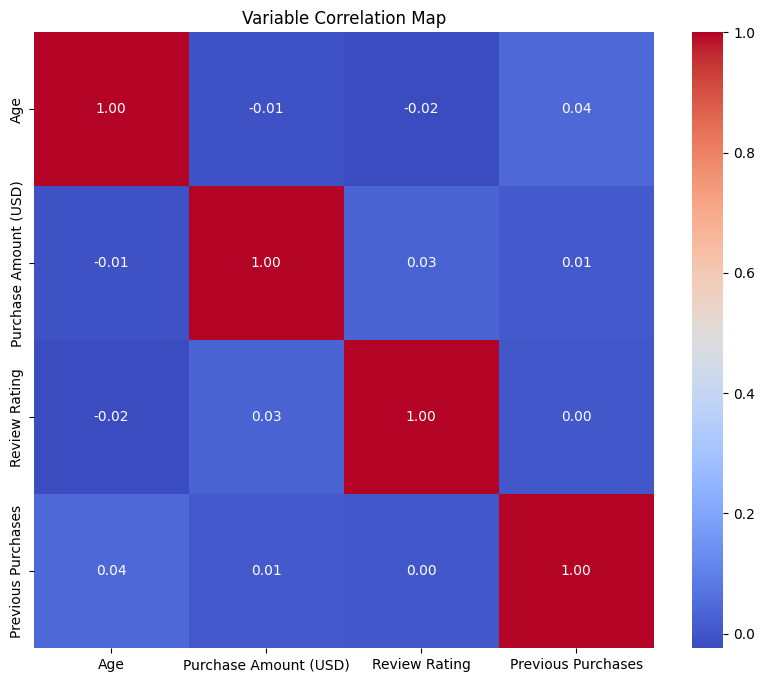

In [45]:
plt.figure(figsize=(10, 8))
corr = df[['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Variable Correlation Map')
plt.show()

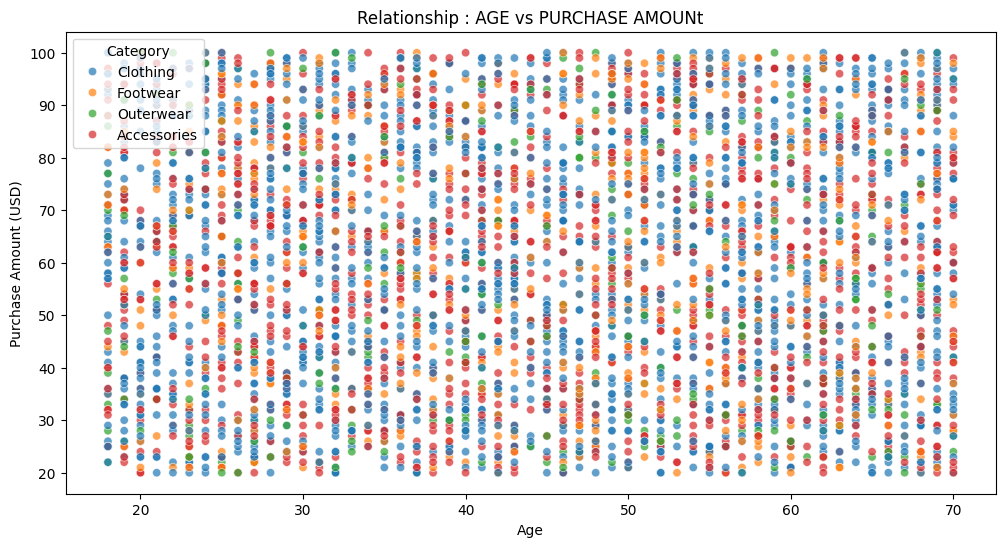

In [46]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Age', y='Purchase Amount (USD)', hue='Category', data=df, alpha=0.7)
plt.title("Relationship : AGE vs PURCHASE AMOUNt")
plt.show()